# Plot Results for the Random Gx/Gx/c Queue Generator

This script generates plots and visual analyses for simulations produced by the random **Gx/Gx/c** queue generator.

### Requirements
- `exp_ggc`

### Authors
- Rafael Andrade  
- Eriky Silva  
- Frederico Cruz  

---

Required packages

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pickle

### Prepare data for plotting

In [17]:
filename = "sim_2026-05-08.pkl"

with open(filename, 'rb') as f:
    results = pickle.load(f)

df_mxm1 = results['sim_MxM1']
df_mmx1 = results['sim_MMx1']
df_mmc = results['sim_MMc']

In [18]:
df_mxm1.head(10)

,lambda,mu,tmax,Wq_mean,Lq_mean,Rho_mean,Wq_var,Lq_var,Rho_var,batch
0,1.0,10.000000,100,0.008729,0.008837,0.101311,0.000020,0.000028,0.000256,1
1,1.0,10.000000,500,0.010732,0.010830,0.102080,0.000010,0.000010,0.000036,1
2,1.0,10.000000,1000,0.010907,0.010971,0.101190,0.000002,0.000002,0.000013,1
3,1.0,10.000000,2000,0.010976,0.011102,0.101491,0.000002,0.000002,0.000010,1
4,1.0,5.000000,100,0.045379,0.046481,0.202986,0.000897,0.001259,0.001446,1
5,1.0,5.000000,500,0.051718,0.052443,0.206190,0.000148,0.000172,0.000197,1
6,1.0,5.000000,1000,0.049080,0.049395,0.202264,0.000048,0.000062,0.000069,1
7,1.0,5.000000,2000,0.050662,0.051293,0.203429,0.000026,0.000036,0.000046,1
8,1.0,3.333333,100,0.145888,0.146075,0.306937,0.004955,0.005736,0.003433,1
9,1.0,3.333333,500,0.135721,0.137153,0.306654,0.001072,0.001243,0.000405,1


### Plotting batch effect
---

#### Plotting design

In [33]:
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "font.size": 12,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "legend.frameon": False,
})

#COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
COLORS = ["#1F3B73", "#A64B2A", "#2F6B4F", "#6B4C9A"]
MARKERS = ["o", "s", "^", "D"]
LINESTYLES = ["-", "--", "-.", ":"]

In [30]:
def plot_metric(df, x, y, xlabel, ylabel):

    df = df[df["tmax"] == df["tmax"].max()] # filter the best estimates
    _, ax = plt.subplots()

    for i, ((lmb, mu), g) in enumerate(df.groupby(["lambda", "mu"])):

        ax.plot(
            g[x],
            g[y],
            color=COLORS[i % len(COLORS)],
            marker=MARKERS[i % len(MARKERS)],
            linestyle=LINESTYLES[i % len(LINESTYLES)],
            linewidth=2,
            label=rf"$\lambda/\mu = {lmb/mu:.2f}$"
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(g[x].unique())

    ax.legend()
    plt.tight_layout()
    plt.show()


#### Mx/M/1

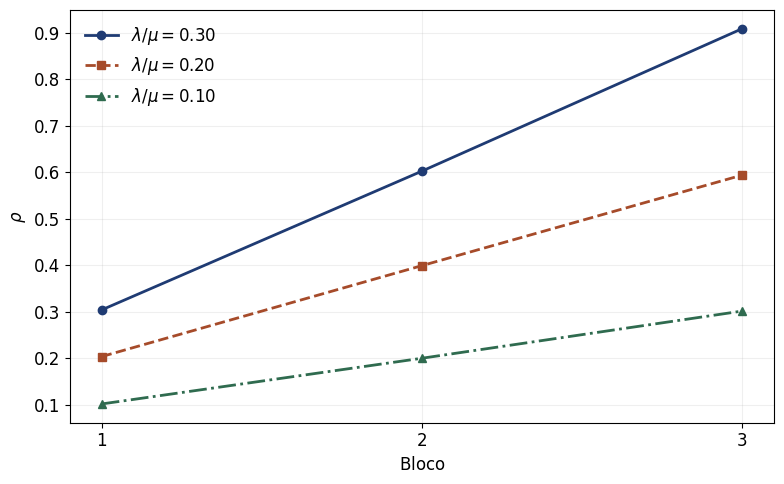

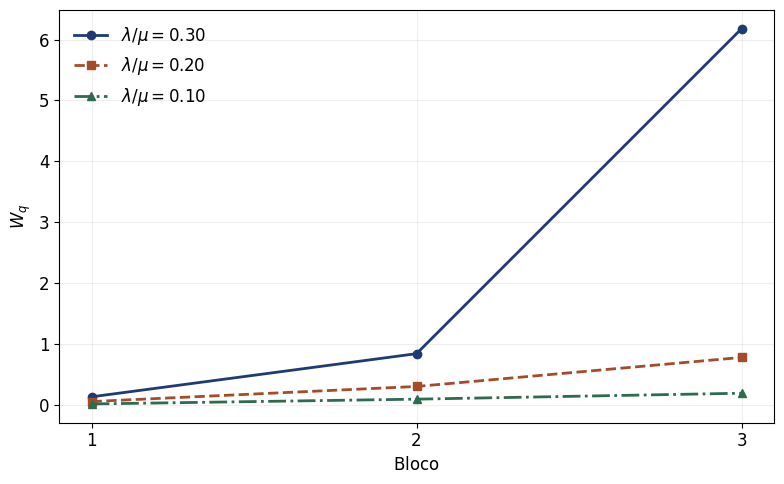

In [32]:
plot_metric(df_mxm1,"batch", "Rho_mean", r"$\mathrm{Bloco}$", r"$\rho$")
plot_metric(df_mxm1, "batch","Wq_mean", r"$\mathrm{Bloco}$", r"$W_q$")

#### M/Mx/1

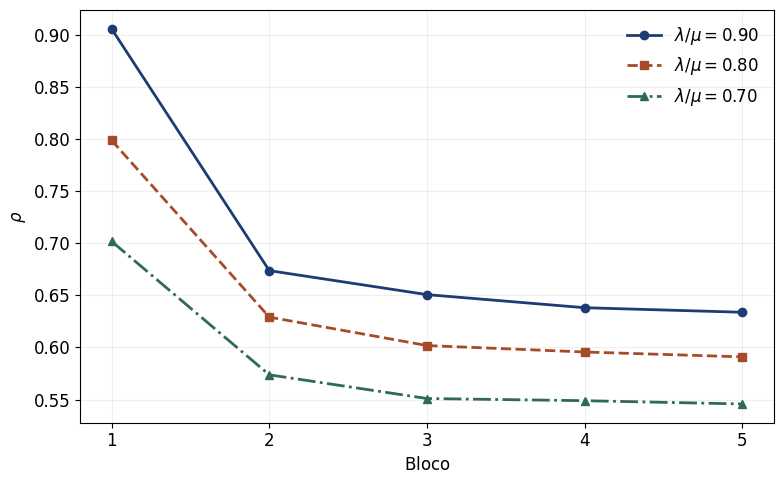

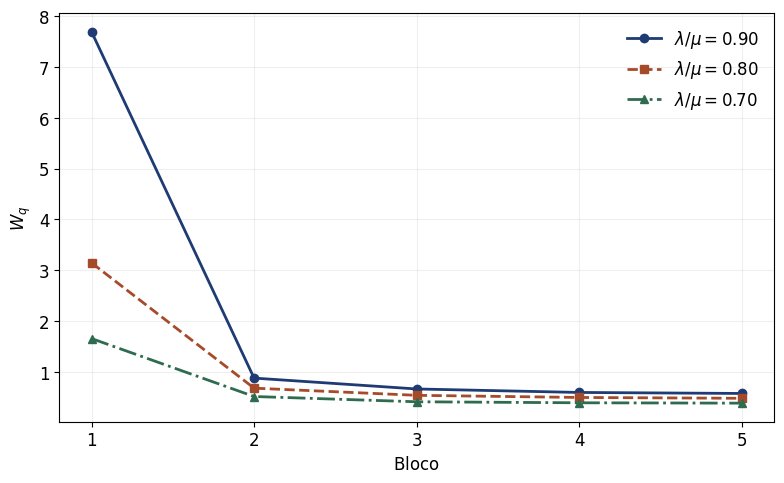

In [38]:
plot_metric(df_mmx1,"batch", "Rho_mean", r"$\mathrm{Bloco}$", r"$\rho$")
plot_metric(df_mmx1, "batch","Wq_mean", r"$\mathrm{Bloco}$", r"$W_q$")

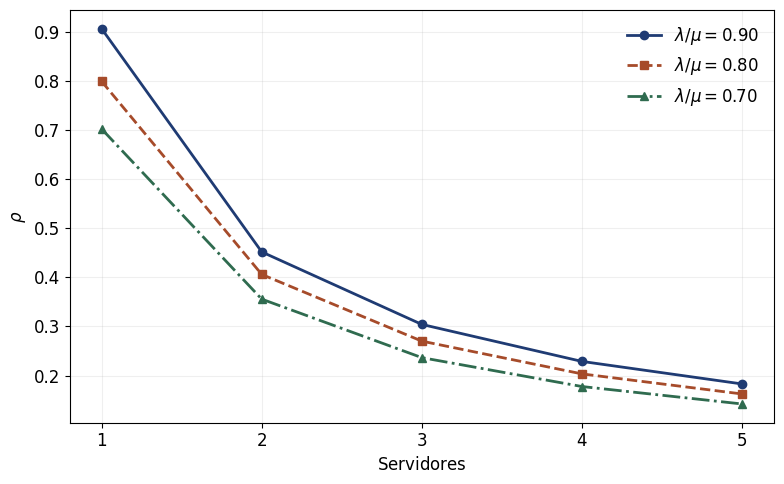

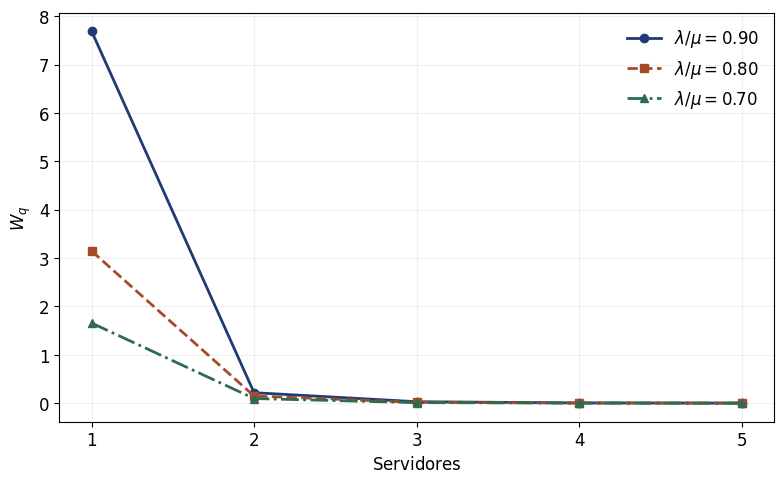

In [40]:
plot_metric(df_mmc, "nserv", "Rho_mean", r"$\mathrm{Servidores}$", r"$\rho$")
plot_metric(df_mmc, "nserv","Wq_mean", r"$\mathrm{Servidores}$", r"$W_q$")

### Plotting convergence
---

In [74]:
def plot_convergence(df, y, ylabel):

    _, ax = plt.subplots()

    for i, ((lmb, mu), g) in enumerate(df.groupby(["lambda", "mu"])):

        g = g.sort_values("tmax")

        ax.plot(
            g["tmax"],
            g[y],
            color=COLORS[i % len(COLORS)],
            marker=MARKERS[i % len(MARKERS)],
            linestyle=LINESTYLES[i % len(LINESTYLES)],
            linewidth=2,
            label=rf"$\lambda/\mu = {lmb/mu:.2f}$"
        )

    ax.set_xlabel(r"$t_{\max}$")
    ax.set_ylabel(ylabel)

    ax.set_xticks(sorted(df["tmax"].unique()))
    ax.set_ylim(0, df[y].max() * 1.4)
    
    ax.legend()

    plt.tight_layout()
    plt.show()

Mx/M/1

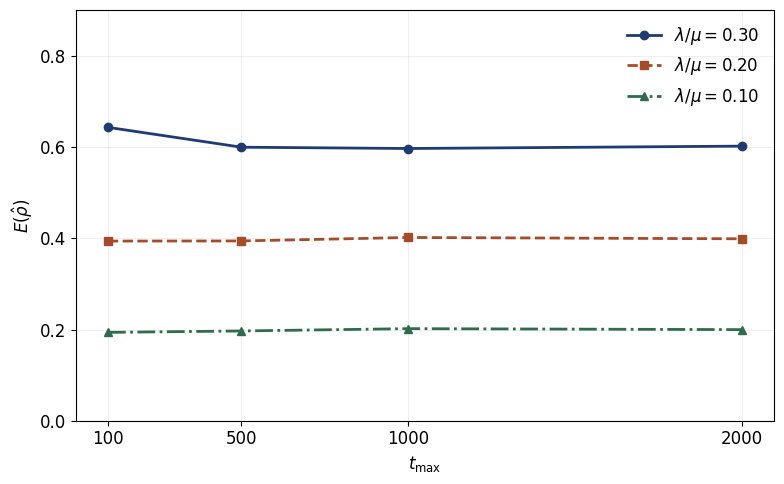

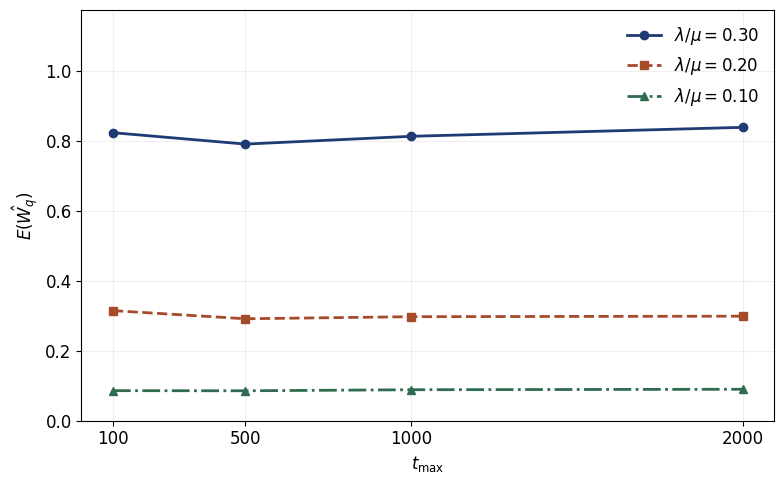

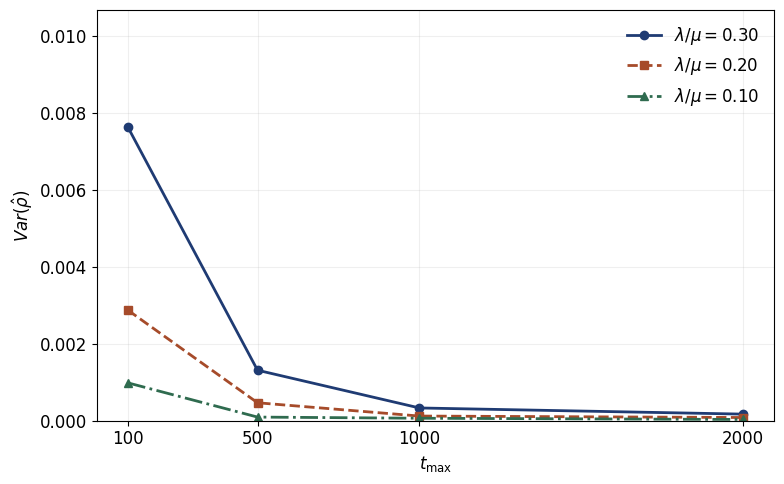

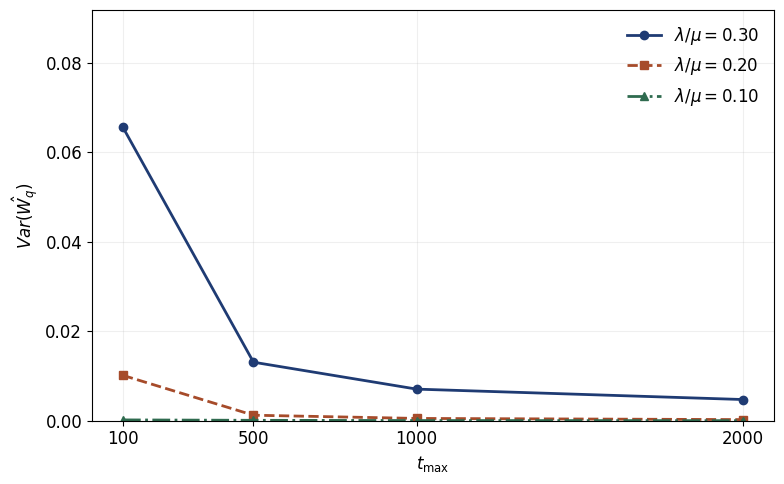

In [76]:
batch_conv = 2
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Rho_mean", r"$E(\hat{\rho})$")
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Wq_mean", r"$E(\hat{W_q})$")
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Rho_var", r"$Var(\hat{\rho})$")
plot_convergence(df_mxm1[df_mxm1["batch"] == batch_conv], "Wq_var", r"$Var(\hat{W_q})$")


M/Mx/1

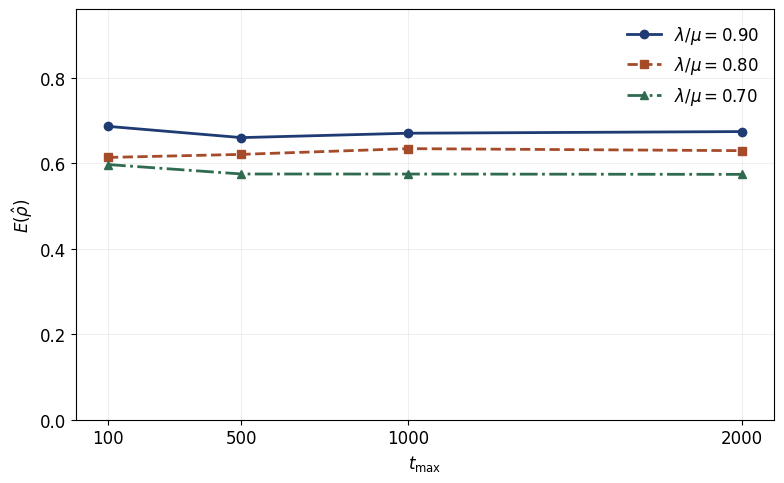

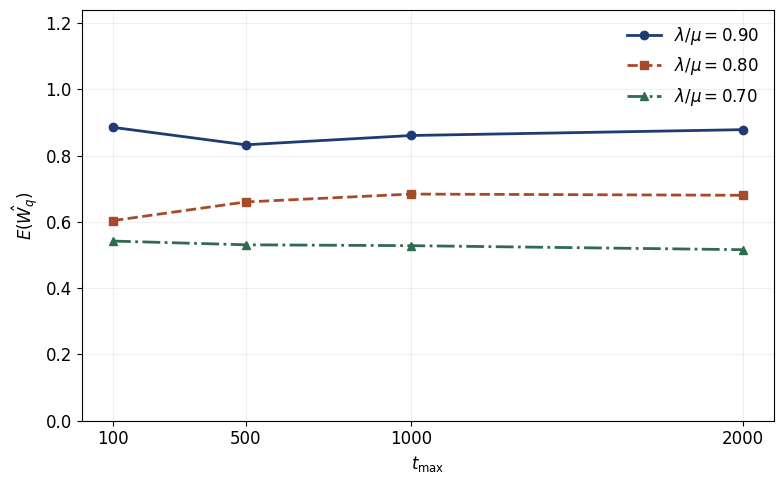

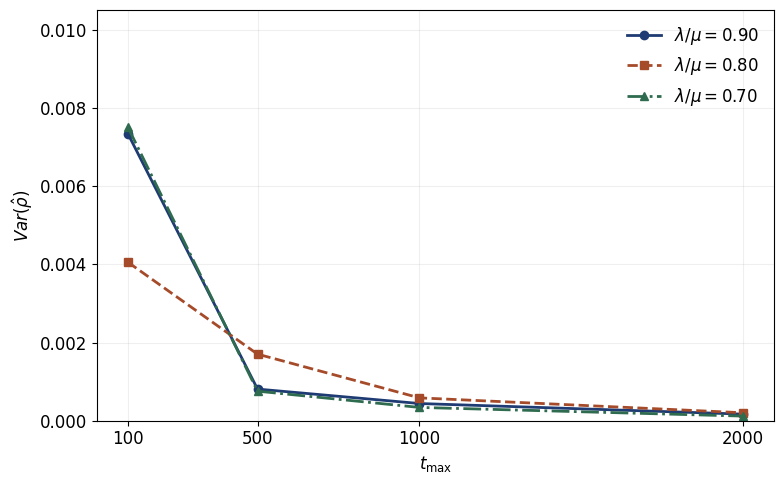

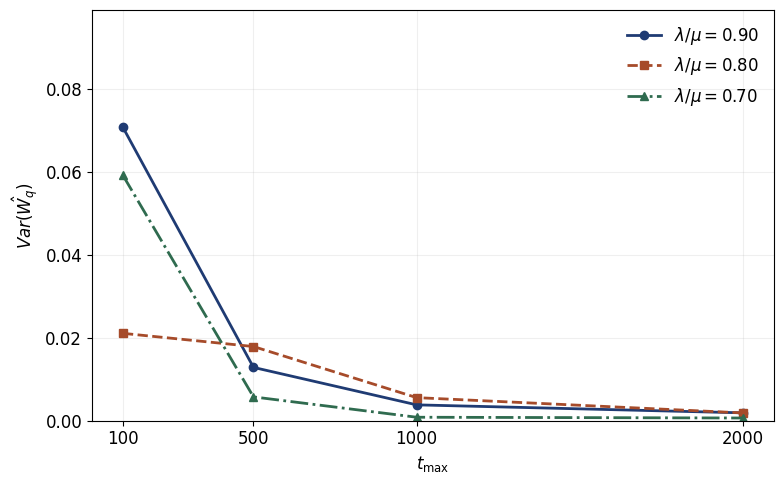

In [77]:
batch_conv = 2
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Rho_mean", r"$E(\hat{\rho})$")
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Wq_mean", r"$E(\hat{W_q})$")
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Rho_var", r"$Var(\hat{\rho})$")
plot_convergence(df_mmx1[df_mmx1["batch"] == batch_conv], "Wq_var", r"$Var(\hat{W_q})$")
